In [1]:
# ------------------------------------------------------------
# CONFIG – edit only the variables below
# ------------------------------------------------------------

EXCEL_FILE = 'all_datasets.xlsx'  # change path if needed
TRAIN_DATASETS = ['camcan', 'ixi', 'npc', 'nimh_rv', 'oasis3', 'pangen', 'sald', 'narratives', 'cbs', 'atag', 'aomic_id1000', 'corr']
TEST_DATASETS  = ['boldvar', 'dallas_lifespan']  

VAL_FRACTION   = 0.10  # informational; we enforce balancing with VAL_PER_GROUP below
VAL_PER_GROUP  = 20    # validation images per (5yr age bin, modality)
RANDOM_STATE   = 42    # reproducibility

# --- global analysis parameters -------------------------------------------
AGE_MIN, AGE_MAX = 20, 80
MODALITIES       = ['t1', 't2', 'flair']


In [2]:
# Imports and helper functions
import os
import fnmatch
import warnings
from typing import Optional, Sequence, Dict, Tuple

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.copy_on_write = True

def normalize_sex(value) -> Optional[str]:
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    if s in {'m', 'male', 'man'}:
        return 'male'
    if s in {'f', 'female', 'woman'}:
        return 'female'
    return s

def normalize_modality(value) -> Optional[str]:
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower().replace(' ', '')
    if s in {'t1w', 't1weighted', 't1-weighted'}:
        return 't1'
    if s in {'t2w', 't2weighted', 't2-weighted'}:
        return 't2'
    if s in {'flair', 't2flair', 't2-flair', 't2_flair'}:
        return 'flair'
    return s

def compute_age_bin5(age) -> Optional[int]:
    try:
        a = float(age)
        return int((a // 5) * 5)  # e.g., 80-85 -> 80
    except Exception:
        return np.nan

def read_master_excel(path: str) -> pd.DataFrame:
    xls = pd.read_excel(path, sheet_name=None)
    frames = []
    for sheet, df in xls.items():
        d = df.copy()
        d.columns = [c.strip().lower() for c in d.columns]
        needed = {'subject_id', 'image_path', 'sex', 'age', 'modality', 'dataset'}
        missing = needed - set(d.columns)
        if missing:
            raise ValueError(f"Sheet '{sheet}' missing columns: {sorted(missing)}")
        d = d[list(needed)].copy()
        frames.append(d)
    all_df = pd.concat(frames, ignore_index=True)
    # Normalize fields
    all_df['subject_id'] = all_df['subject_id'].astype(str)
    all_df['image_path'] = all_df['image_path'].astype(str)
    all_df['dataset']    = all_df['dataset'].astype(str).str.strip().str.lower()
    all_df['sex']        = all_df['sex'].map(normalize_sex)
    all_df['modality']   = all_df['modality'].map(normalize_modality)
    all_df['age']        = pd.to_numeric(all_df['age'], errors='coerce')
    # Drop rows with missing essentials
    all_df = all_df.dropna(subset=['image_path', 'age', 'modality', 'dataset'])
    # Compute 5-year age bin
    all_df['5_age_bin'] = all_df['age'].apply(compute_age_bin5)
    # Deduplicate identical (subject_id, image_path)
    all_df = all_df.drop_duplicates(subset=['subject_id', 'image_path'])
    return all_df.reset_index(drop=True)

def remove_by_patterns(df: pd.DataFrame, patterns: Sequence[str]) -> pd.DataFrame:
    """Remove rows where image_path matches ANY of the glob patterns."""
    if not patterns:
        print('No removal patterns provided.')
        return df
    paths = df['image_path'].astype(str).values
    # Start with keeping all; set to False if any pattern matches
    keep_mask = np.ones(len(paths), dtype=bool)
    for pat in patterns:
        matches = np.array([fnmatch.fnmatch(p, pat) for p in paths])
        keep_mask &= ~matches
    removed = int((~keep_mask).sum())
    print(f"Removed {removed} rows by patterns ({len(patterns)} patterns).")
    return df.loc[keep_mask].reset_index(drop=True)

def make_balanced_validation(df_train_pool: pd.DataFrame, per_group: int, random_state: int) -> pd.Index:
    """Sample up to `per_group` from each (5_age_bin, modality) group for validation."""
    if df_train_pool.empty:
        return pd.Index([], dtype=int)
    groups = df_train_pool.groupby(['5_age_bin', 'modality'], dropna=False)
    idx_parts = []
    for (age_bin, mod), g in groups:
        n = min(per_group, len(g))
        if n > 0:
            idx_parts.append(g.sample(n=n, random_state=random_state, replace=False).index)
    if not idx_parts:
        return pd.Index([], dtype=int)
    return pd.Index(np.concatenate([idx.values for idx in idx_parts]))

def compute_sampling_weights(train_df: pd.DataFrame) -> Tuple[Dict[float, float], Dict[Tuple[float, str], float]]:
    """
    age_frequency:              N_train / count(age)
    age_modality_frequency:     N_train / count((age, modality))
    Computed STRICTLY on training set after validation removal.
    """
    N = len(train_df)
    if N == 0:
        return {}, {}
    age_counts = train_df.groupby('age').size()
    age_mod_counts = train_df.groupby(['age', 'modality']).size()
    age_freq = (N / age_counts).to_dict()
    age_mod_freq = (N / age_mod_counts).to_dict()
    return age_freq, age_mod_freq

def attach_weights(df: pd.DataFrame) -> pd.DataFrame:
    """
    For a given split df, compute per-row probabilities that sum to 1:
    - age_frequency: inverse of count(age_int), normalized over all rows
    - age_modality_frequency: inverse of count((age_int, modality)), normalized over all rows
    """
    out = df.copy()
    if out.empty:
        out['age_frequency'] = np.nan
        out['age_modality_frequency'] = np.nan
        return out

    out['age_bin'] = out['age'].astype(int)

    age_counts = out.groupby('age_bin').size().rename('freq_age')
    age_mod_counts = out.groupby(['age_bin', 'modality']).size().rename('freq_age_mod')

    out = out.join(age_counts, on='age_bin').join(age_mod_counts, on=['age_bin', 'modality'])

    out['age_frequency'] = 1.0 / out['freq_age']
    out['age_modality_frequency'] = 1.0 / out['freq_age_mod']

    out['age_frequency'] /= out['age_frequency'].sum()
    out['age_modality_frequency'] /= out['age_modality_frequency'].sum()

    return out.drop(columns=['age_bin', 'freq_age', 'freq_age_mod'])

def plot_count_heatmap(df: pd.DataFrame,
                       title: str = '',
                       *,
                       group_by: int = 1,        # age bin width (years)
                       cmap: str   = 'YlGnBu',
                       log_scale: bool = False,
                       save_as: Optional[str] = None):
    needed = {'age', 'sex', 'modality'}
    if not needed.issubset(df.columns):
        raise ValueError(f'DataFrame must contain {needed}')

    present = df.copy()
    present['age'] = pd.to_numeric(present['age'], errors='coerce')
    present = present.dropna(subset=['age'])
    present['sex'] = present['sex'].map(normalize_sex)
    present['modality'] = present['modality'].map(normalize_modality)
    present['age_bin'] = (present['age'] // group_by) * group_by

    ages   = list(range(AGE_MIN, AGE_MAX + 1, group_by))
    combos = [(m, s) for m in MODALITIES for s in ['male', 'female']]

    mat = np.zeros((len(combos), len(ages)), dtype=int)
    for r, (mod, sex) in enumerate(combos):
        sub = present[(present['modality'] == mod) & (present['sex'] == sex)]
        counts = sub.groupby('age_bin').size()
        for c, age in enumerate(ages):
            mat[r, c] = int(counts.get(age, 0))

    plot_mat = np.log1p(mat) if log_scale else mat
    cbar_lbl = 'log_e(1 + count)' if log_scale else 'count'

    fig_h = max(3, 0.6 * len(combos))
    plt.figure(figsize=(18, fig_h))
    sns.heatmap(plot_mat,
                cmap=cmap,
                annot=True,
                fmt='.0f',
                linewidths=.5,
                cbar_kws={'label': cbar_lbl},
                xticklabels=ages,
                yticklabels=[f'{m.upper()} – {s.capitalize()}' for m, s in combos])

    plt.title(f'{title}\ncell value = number of images', fontsize=14)
    plt.xlabel('Age')
    plt.ylabel('Modality / Sex')
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save_as:
        os.makedirs(os.path.dirname(save_as) or '.', exist_ok=True)
        plt.savefig(save_as, dpi=150)
    plt.show()


In [3]:
# Load and prepare the master Excel
df_all = read_master_excel(EXCEL_FILE)

# Filter by age range
df_all = df_all[(df_all['age'] >= AGE_MIN) & (df_all['age'] <= AGE_MAX)]
print(f"Rows after filtering to age range {AGE_MIN}-{AGE_MAX}: {len(df_all)}")


# Harmonize dataset lists
TRAIN_DATASETS = [d.strip().lower() for d in TRAIN_DATASETS]
TEST_DATASETS  = [d.strip().lower() for d in TEST_DATASETS]

overlap = set(TRAIN_DATASETS) & set(TEST_DATASETS)
if overlap:
    raise ValueError(f"Datasets overlap between TRAIN and TEST: {sorted(overlap)}")

present_sets = sorted(df_all['dataset'].dropna().unique())
print('Datasets found in Excel:', present_sets)

missing_train = sorted(set(TRAIN_DATASETS) - set(present_sets))
missing_test  = sorted(set(TEST_DATASETS)  - set(present_sets))
if missing_train:
    print('Warning: Train datasets not found:', missing_train)
if missing_test:
    print('Warning: Test datasets not found:', missing_test)

# Keep only rows from datasets we care about (TRAIN or TEST)
df_all = df_all[df_all['dataset'].isin(TRAIN_DATASETS + TEST_DATASETS)].reset_index(drop=True)
print(f"Rows after filtering to TRAIN+TEST datasets: {len(df_all)}")

# Ensure canonical fields before any filtering/splitting
df_all['sex'] = df_all['sex'].map(normalize_sex)
df_all['modality'] = df_all['modality'].map(normalize_modality)
df_all['5_age_bin'] = df_all['age'].apply(compute_age_bin5)


Rows after filtering to age range 20-80: 9185
Datasets found in Excel: ['aomic_id1000', 'atag', 'boldvar', 'camcan', 'cbs', 'corr', 'dallas_lifespan', 'ixi', 'narratives', 'nimh_rv', 'npc', 'oasis3', 'pangen', 'sald']
Rows after filtering to TRAIN+TEST datasets: 9185


In [4]:
# Pattern lists – edit/extend these as needed

nimhrv_filenames = [r"*HighResHippo*"]  # Regex-like glob for substring match

oasis_filenames = [
    r"*sub-OAS30367_ses-d0055_run-01_T1w*",
    r"*sub-OAS30297_ses-d0105_run-01_T1w*",
    r"*sub-OAS30581_ses-d0104_run-01_T1w*",
    r"*sub-OAS31031_ses-d0069_run-01_T1w*",
    r"*sub-OAS30062_ses-d0087_run-01_T1w*",
    r"*sub-OAS30249_ses-d0091_run-01_T1w*",
    r"*sub-OAS30020_ses-d0092_run-04_T1w*",
    r"*sub-OAS30020_ses-d0092_run-01_T1w*",
    r"*sub-OAS30103_ses-d3306_run-01_T1w*",
    r"*sub-OAS30660_ses-d0087_run-01_T1w*",
    r"*sub-OAS30516_ses-d0225_run-01_T1w*",
    r"*sub-OAS30946_ses-d0096_run-01_T1w*",
    r"*sub-OAS30960_ses-d0061_run-01_T1w*",
    r"*sub-OAS31064_ses-d0054_run-04_T1w*",
    r"*sub-OAS30919_ses-d0035_run-01_T1w*",
    r"*sub-OAS30558_ses-d0061_run-01_T1w*",
    r"*sub-OAS30278_ses-d0028_run-01_T1w*",
    r"*sub-OAS30444_ses-d0001_run-04_T1w*",
    r"*sub-OAS30969_ses-d0047_run-01_T1w*",
    r"*sub-OAS30284_ses-d0094_run-01_T1w*",
    r"*sub-OAS30876_ses-d0126_run-01_T1w*",
    r"*sub-OAS30365_ses-d5600_run-01_T1w*",
    r"*sub-OAS30459_ses-d0078_run-01_T1w*",
    r"*sub-OAS30278_ses-d0028_run-04_T1w*",
    r"*sub-OAS30188_ses-d0246_run-01_T1w*",
    r"*sub-OAS30803_ses-d0086_run-01_T1w*",
    r"*sub-OAS30960_ses-d0061_run-04_T1w*",
    r"*sub-OAS31103_ses-d0170_run-01_T1w*",
    r"*sub-OAS30794_ses-d1680_run-01_T1w*",
    r"*sub-OAS31014_ses-d0133_run-01_T1w*",
    r"*sub-OAS30032_ses-d0262_run-01_T1w*",
    r"*sub-OAS30303_ses-d0910_run-01_T1w*",
    r"*sub-OAS30048_ses-d0983_run-01_T1w*",
    r"*sub-OAS31058_ses-d0877_run-01_T1w*",
    r"*sub-OAS30412_ses-d6024_run-01_T1w*",
    r"*sub-OAS30709_ses-d0026_run-04_T1w*",
    r"*sub-OAS31072_ses-d0833_run-01_T1w*",
    r"*sub-OAS30699_ses-d0108_run-01_T1w*",
    r"*sub-OAS30106_ses-d2982_run-01_T1w*",
    r"*sub-OAS31012_ses-d0308_run-01_T1w*",
    r"*sub-OAS30676_ses-d0861_run-01_T1w*",
    r"*sub-OAS30718_ses-d5999_run-01_T1w*",
    r"*sub-OAS30192_ses-d0293_run-01_T1w*",
    r"*sub-OAS30444_ses-d0001_run-01_T1w*",
    r"*sub-OAS30121_ses-d0768_run-01_T1w*",
    r"*sub-OAS30216_ses-d2849_run-01_T1w*",
    r"*sub-OAS30131_ses-d0086_run-01_T1w*",
    r"*sub-OAS30411_ses-d0183_run-01_T1w*",
    r"*sub-OAS30709_ses-d0026_run-01_T1w*",
    r"*sub-OAS30920_ses-d0155_run-01_T1w*",
    r"*sub-OAS30963_ses-d0047_run-01_T1w*",
    r"*sub-OAS30121_ses-d0768_run-04_T1w*",
    r"*sub-OAS30776_ses-d0308_run-01_T1w*",
    r"*sub-OAS30288_ses-d0897_run-01_T1w*",
    r"*sub-OAS30494_ses-d0059_run-01_T1w*",
    r"*sub-OAS31064_ses-d0054_run-01_T1w*",
    r"*sub-OAS30786_ses-d0286_run-01_T1w*",
    r"*sub-OAS30689_ses-d2082_run-01_T1w*",
    r"*sub-OAS30470_ses-d1023_run-01_T1w*",
    r"*sub-OAS30073_ses-d0033_run-04_T1w*",
    r"*sub-OAS30841_ses-d0187_run-01_T1w*",
    r"*sub-OAS31081_ses-d0129_run-01_T1w*",
    r"*sub-OAS30073_ses-d0033_run-01_T1w*",
    r"*sub-OAS30852_ses-d2307_run-04_T1w*",
    r"*sub-OAS30588_ses-d0394_run-01_T1w*",
    r"*sub-OAS31167_ses-d0064_run-01_T1w*",
    r"*sub-OAS30455_ses-d0171_run-01_T1w*",
    r"*sub-OAS30872_ses-d0179_run-01_T1w*",
    r"*sub-OAS30059_ses-d0230_run-04_T1w*",
    r"*sub-OAS30698_ses-d0975_run-04_T1w*",
    r"*sub-OAS30742_ses-d0058_run-01_T1w*",
    r"*sub-OAS30852_ses-d2307_run-01_T1w*",
    r"*sub-OAS30698_ses-d0975_run-01_T1w*",
    r"*sub-OAS30059_ses-d0230_run-01_T1w*",
    r"*sub-OAS30829_ses-d5823_run-01_T1w*"
]

corr_filenames = [
    r"*sub-0026019_ses-1_run-1_T1w*",
    r"*sub-0026034_ses-1_run-1_T1w*",
    r"*sub-0026034_ses-1_run-1_T1w*",
    r"*sub-0027439_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027430_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027437_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027432_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027438_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027433_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027434_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027436_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027431_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027447_ses-1_acq-inv1phs_run-1_T1w*",
    r"*sub-0027440_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027435_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027436_ses-1_acq-inv2phs_run-1_T1w*"
]

# Add additional lists here if needed, then combine
REMOVE_PATTERNS = oasis_filenames + nimhrv_filenames + corr_filenames


In [5]:
# Apply pattern-based removals
before = len(df_all)
df_all = remove_by_patterns(df_all, REMOVE_PATTERNS)
after = len(df_all)
print(f"Total removed by patterns: {before - after}")


Removed 73 rows by patterns (92 patterns).
Total removed by patterns: 73


In [6]:
# Create TRAIN / VAL / TEST splits and compute frequencies

# Split by dataset
train_pool = df_all[df_all['dataset'].isin(TRAIN_DATASETS)].copy()
test_df    = df_all[df_all['dataset'].isin(TEST_DATASETS)].copy()

print(f"Train pool size: {len(train_pool)} | Test size: {len(test_df)}")

# Balanced validation: up to VAL_PER_GROUP per (5yr bin, modality)
val_idx = make_balanced_validation(train_pool, per_group=VAL_PER_GROUP, random_state=RANDOM_STATE)
val_df = train_pool.loc[val_idx].copy()
train_df = train_pool.drop(index=val_idx).copy()

print(f"Validation size: {len(val_df)} (target ~{int(len(train_pool)*VAL_FRACTION)} by fraction)")

# Compute sampling weights using only the finalized training set
age_freq_map, age_mod_freq_map = compute_sampling_weights(train_df)

# Attach weights to all splits (weights derived from training distribution)
train_df = attach_weights(train_df)
val_df   = attach_weights(val_df )
test_df  = attach_weights(test_df)


# Ensure column orderf
COL_ORDER = ['subject_id', 'image_path', 'sex', 'age', 'modality', 'dataset', '5_age_bin', 'age_frequency', 'age_modality_frequency']
for name in ['train_df', 'val_df', 'test_df']:
    df = locals()[name]
    for col in COL_ORDER:
        if col not in df.columns:
            df[col] = np.nan
    locals()[name] = df[COL_ORDER].copy()

# T1-only label sets (validation reuses the same images but filtered to T1)
train_t1_df = train_df[train_df['modality'] == 't1'].copy()
val_t1_df   = val_df[val_df['modality'] == 't1'].copy()
test_t1_df  = test_df[test_df['modality'] == 't1'].copy()


labels_dir = '../labels/'
train_df.to_csv(f'{labels_dir}train_labels.csv', index=False)
val_df.to_csv(f'{labels_dir}val_labels.csv', index=False)
test_df.to_csv(f'{labels_dir}test_labels.csv', index=False)
train_t1_df.to_csv(f'{labels_dir}train_t1_labels.csv', index=False)
val_t1_df.to_csv(f'{labels_dir}val_t1_labels.csv', index=False)
test_t1_df.to_csv(f'{labels_dir}test_t1_labels.csv', index=False)

print('Saved: train_labels.csv, val_labels.csv, test_labels.csv, train_t1_labels.csv, val_t1_labels.csv, test_t1_labels.csv')
print(f'Files saved to: {labels_dir}')

# Quick summary
print('\nSummary counts:')
print(f"  Train: {len(train_df)} | T1: {len(train_t1_df)}")
print(f"  Val:   {len(val_df)}   | T1: {len(val_t1_df)}")
print(f"  Test:  {len(test_df)}  | T1: {len(test_t1_df)}\n")

print('Validation counts per (5yr bin, modality):')
val_group = val_df.groupby(['5_age_bin', 'modality']).size().reset_index(name='count').sort_values(['modality','5_age_bin'])
# display(val_group)


Train pool size: 7984 | Test size: 1128
Validation size: 756 (target ~798 by fraction)
Saved: train_labels.csv, val_labels.csv, test_labels.csv, train_t1_labels.csv, val_t1_labels.csv, test_t1_labels.csv
Files saved to: ../labels/

Summary counts:
  Train: 7228 | T1: 5006
  Val:   756   | T1: 258
  Test:  1128  | T1: 562

Validation counts per (5yr bin, modality):


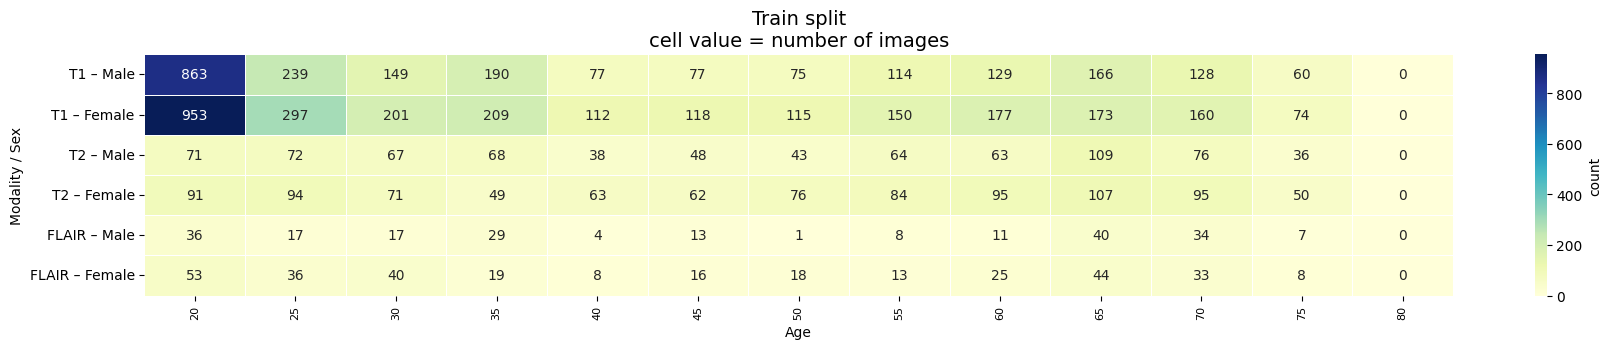

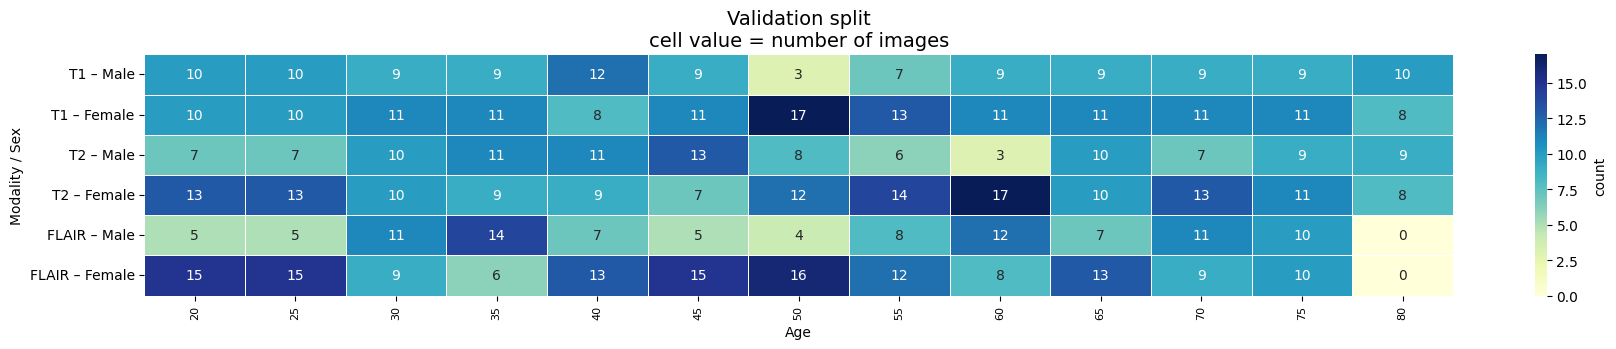

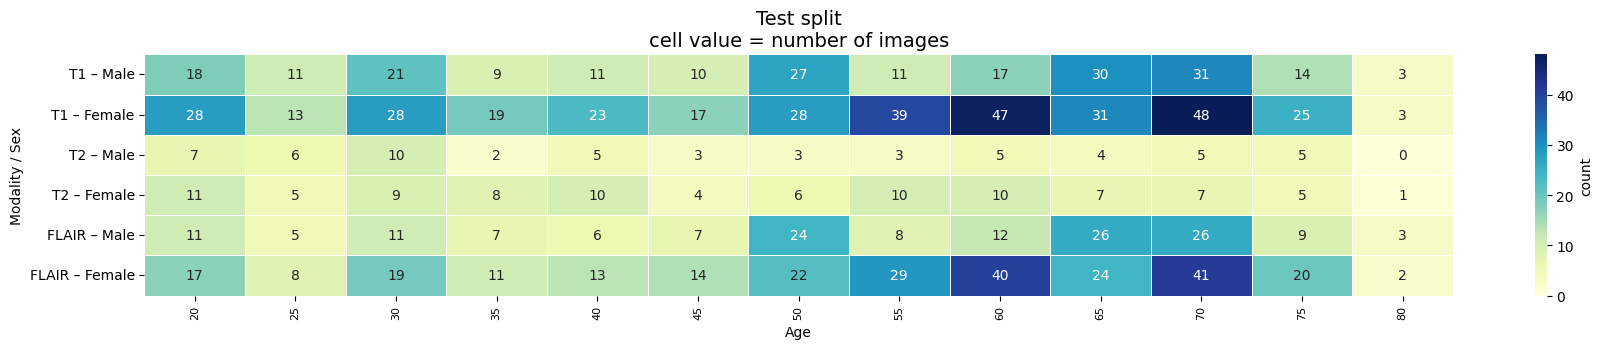

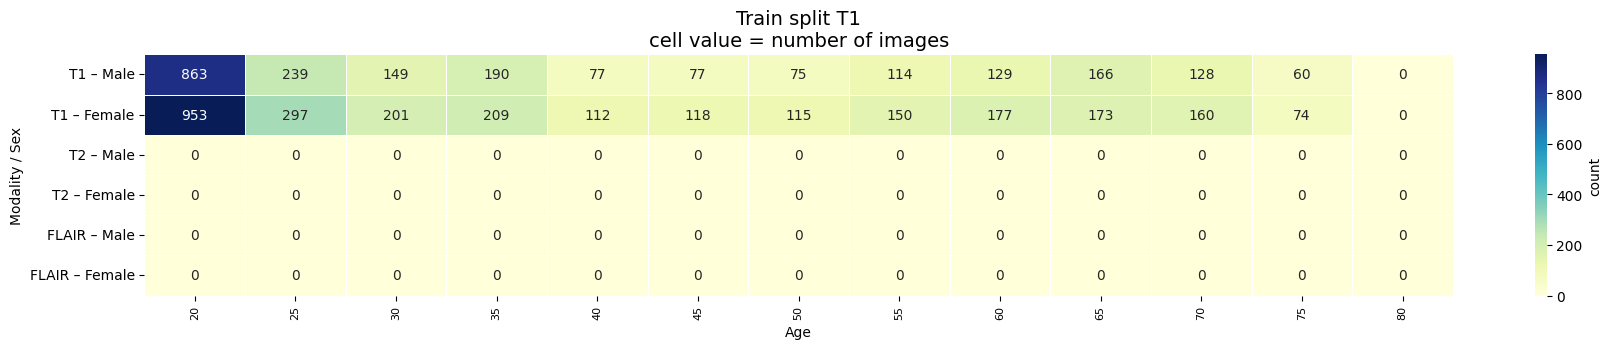

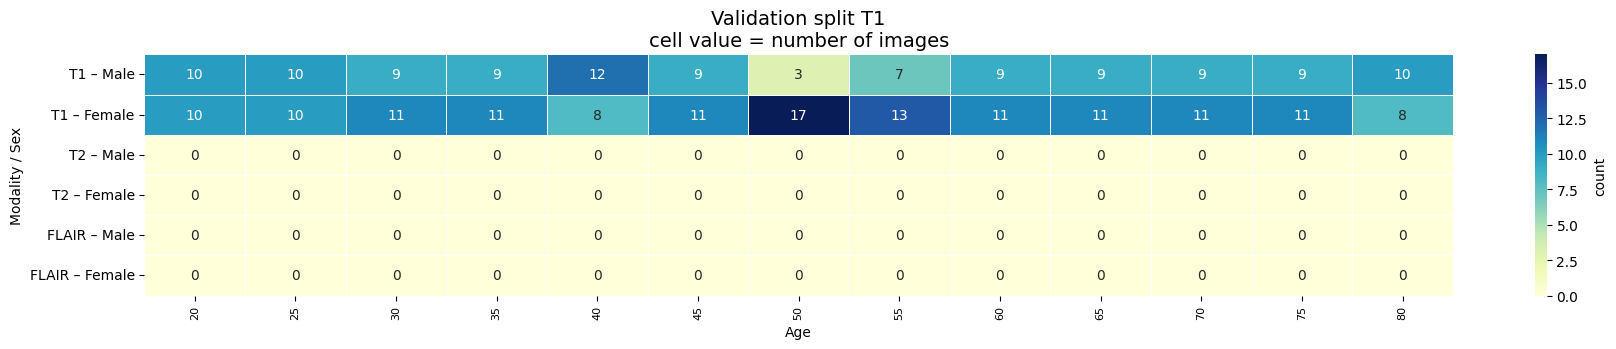

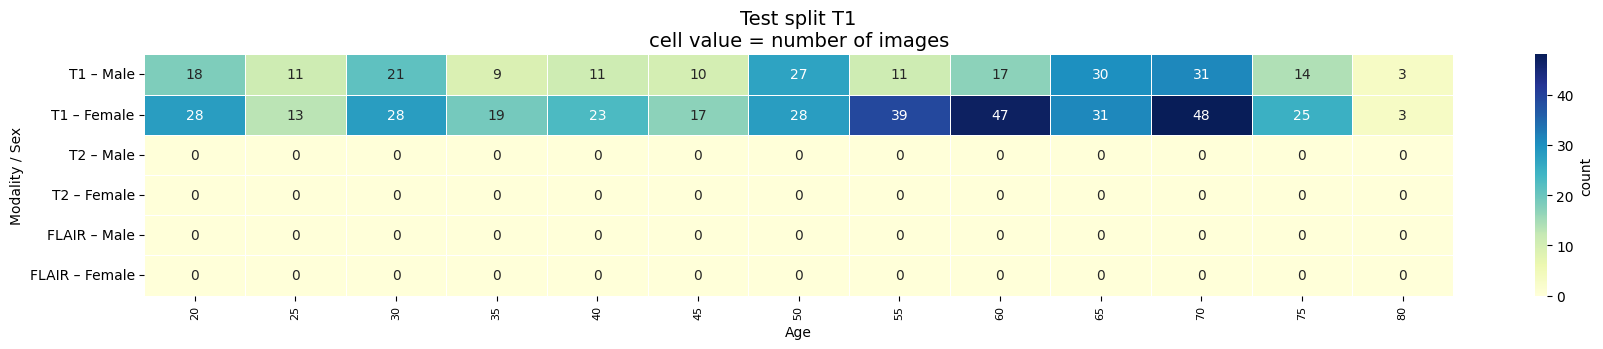

Saved heatmaps under ./plots/


In [7]:
# Generate heatmaps per dataset and for each split
os.makedirs('plots', exist_ok=True)

# # # # Per-dataset heatmaps across the full (kept) data
# for ds in sorted(df_all['dataset'].dropna().unique()):
#     sub = df_all[df_all['dataset'] == ds]
#     if len(sub) == 0:
#         continue
#     plot_count_heatmap(sub, title=f'Dataset: {ds}', group_by=5, cmap='YlGnBu', log_scale=False, save_as=f'plots/heatmap_{ds}.png')

# Split heatmaps
plot_count_heatmap(train_df, title='Train split', group_by=5, cmap='YlGnBu', log_scale=False, save_as='plots/heatmap_train.png')
plot_count_heatmap(val_df,   title='Validation split', group_by=5, cmap='YlGnBu', log_scale=False, save_as='plots/heatmap_val.png')
plot_count_heatmap(test_df,  title='Test split', group_by=5, cmap='YlGnBu', log_scale=False, save_as='plots/heatmap_test.png')

plot_count_heatmap(train_t1_df, title='Train split T1', group_by=5, cmap='YlGnBu', log_scale=False, save_as='plots/heatmap_train_t1.png')
plot_count_heatmap(val_t1_df,   title='Validation split T1', group_by=5, cmap='YlGnBu', log_scale=False, save_as='plots/heatmap_val_t1.png')
plot_count_heatmap(test_t1_df,  title='Test split T1', group_by=5, cmap='YlGnBu', log_scale=False, save_as='plots/heatmap_test_t1.png')

print("Saved heatmaps under ./plots/")
